# graphed plot

weighted_graph의 dong 별로 actual 값을 전체 기간으로 확인  

In [3]:
# load module
import os
#os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.float_format', '{:,.7f}'.format)
from pathlib import Path

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger


from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

import tensorflow as tf 
import tensorboard as tb 
tf.io.gfile = tb.compat.tensorflow_stub.io.gfile

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

dongs = sorted(pd.read_csv('ewma_5h.csv')['h_dong'].unique())

/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(


In [14]:
def data_processing(path = '../../sample_table/ewma_6h_scaling.csv'):
    data = pd.read_csv(path)
    
    #data.drop('Unnamed: 0.2'   , axis=1 , inplace=True)
    #data.drop('Unnamed: 0.1'   , axis=1 , inplace=True)
    data.drop('Unnamed: 0'   , axis=1 , inplace=True)
    #data.drop('nei1' , axis=1 , inplace=True)
    #data.drop('nei2' , axis=1 , inplace=True)
    data['REG_DTIME'] = pd.to_datetime(data['REG_DTIME'])
    data['DOW'] = data['REG_DTIME'].dt.dayofweek
    data['HOD'] = data['REG_DTIME'].dt.hour
    data["time_idx"] =  \
    (data["REG_DTIME"].dt.month) * data["REG_DTIME"].dt.daysinmonth * 24  + \
    data["REG_DTIME"].dt.day * 24  + \
    data["REG_DTIME"].dt.hour 
    data["time_idx"] -= data["time_idx"].min()
    #data['h_dong'] = data['h_dong'].astype(str)
    data['DOW'] = data['DOW'].astype(str)
    data['HOD'] = data['HOD'].astype(str)
    data['precip_form'] = data['precip_form'].astype(str)
    data['isHoliday'] = data['isHoliday'].astype(str)

    return data

def get_descibe(path):
    return pd.read_csv(path)['count'].describe()

def dong_actual(path):
#    data = data_processing(path)
    data= pd.read_csv(path)
    #data['count'] = data['count'].round() 
    for dong in dongs:
        dong_df = data[data['h_dong'] == dong]
        plt.figure(figsize=(16,4))
        x = np.arange(len(dong_df))[:50]
        plt.scatter(dong_df['REG_DTIME'].index[:50], dong_df['count'][:50] , label=f'{path}' , s= 1)
        plt.title(f'{dong} actual , {path}')
        plt.legend()


# plot

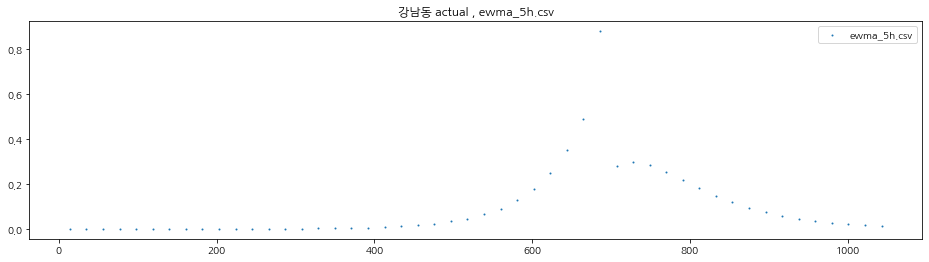

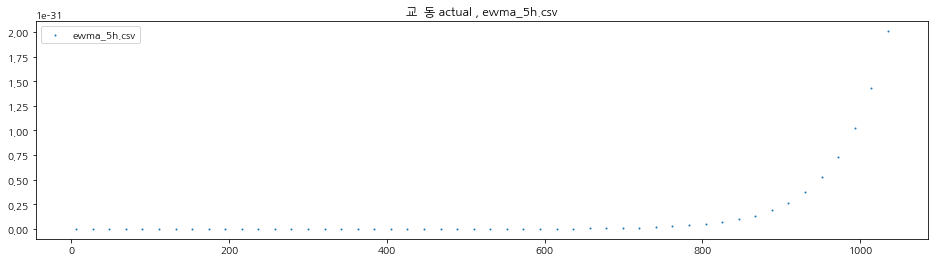

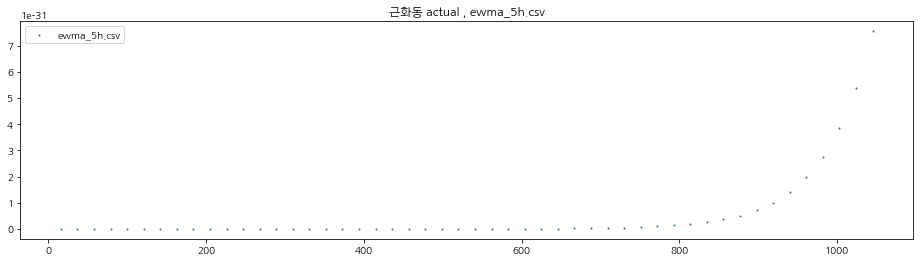

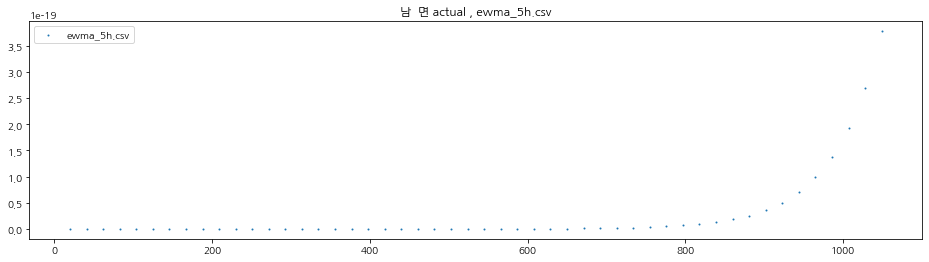

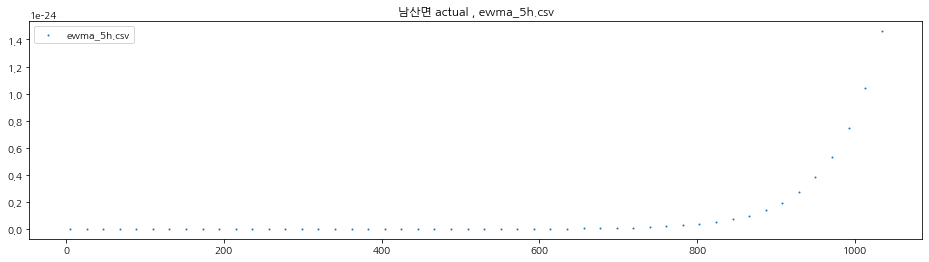

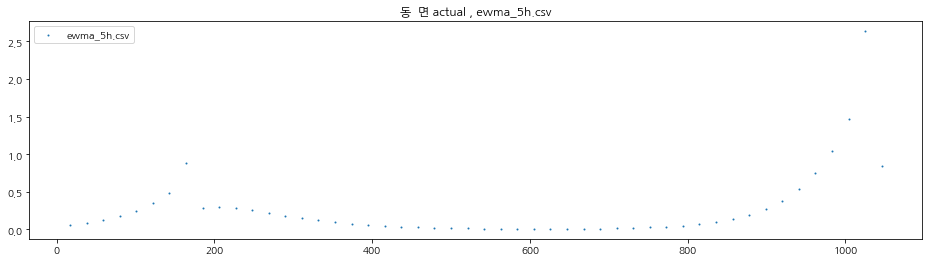

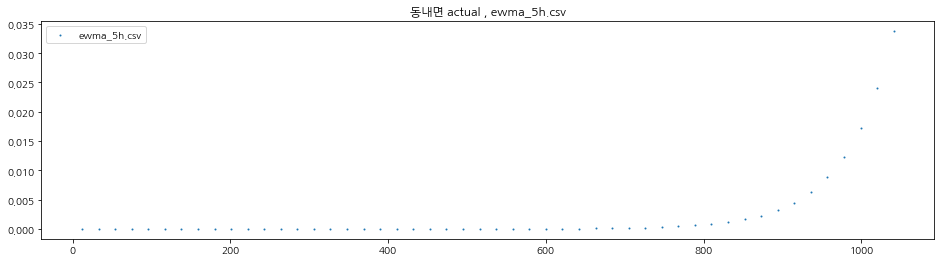

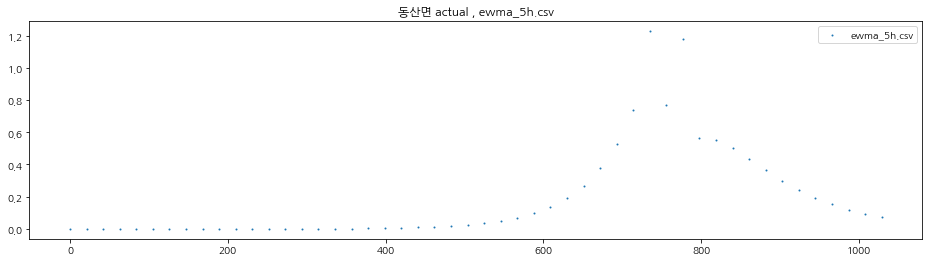

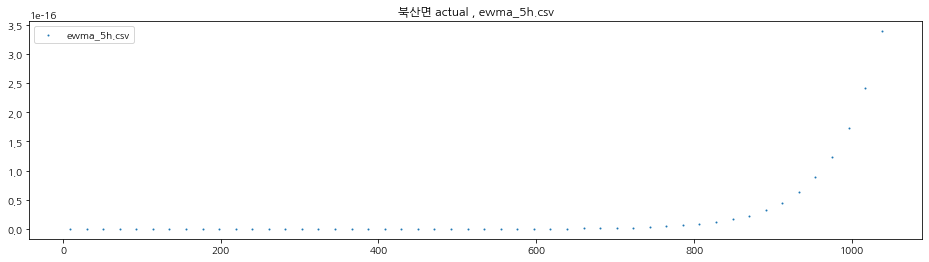

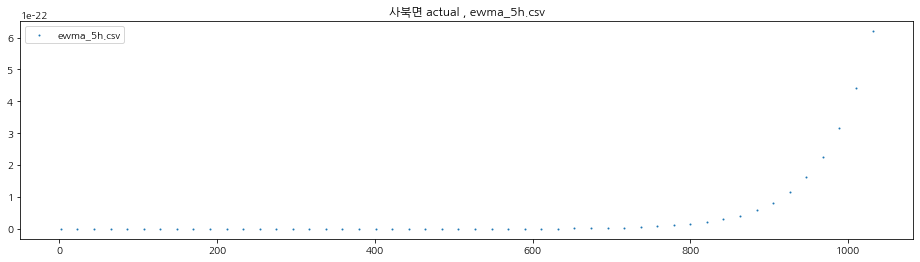

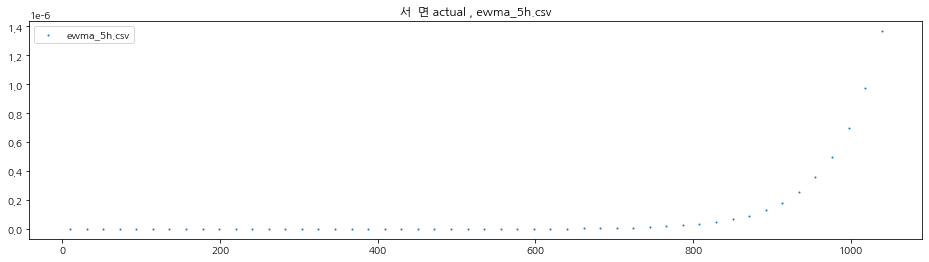

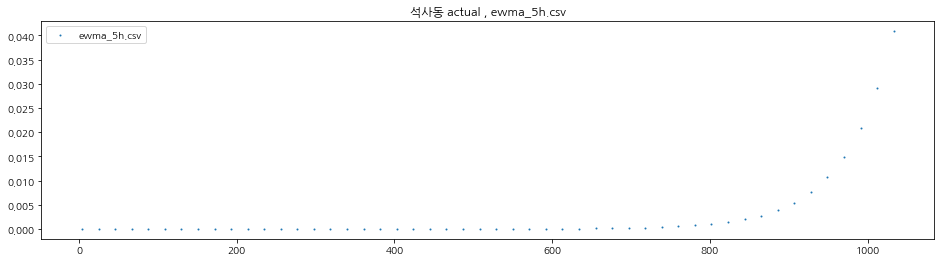

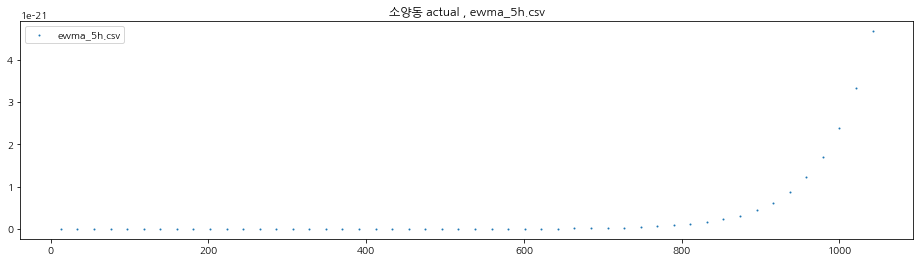

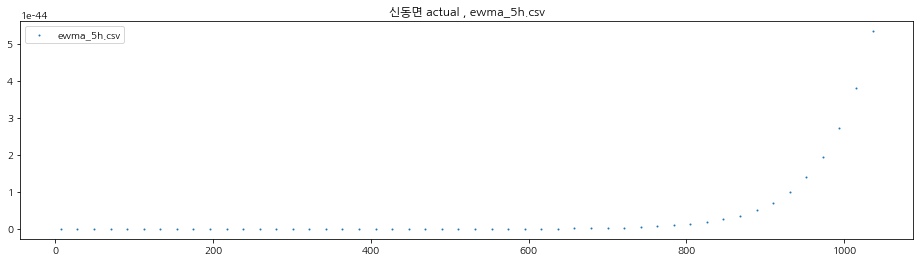

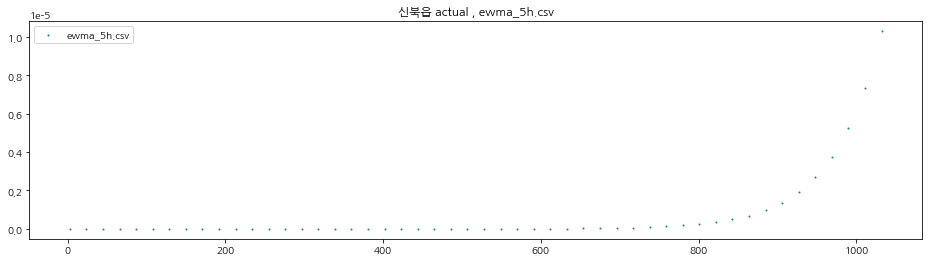

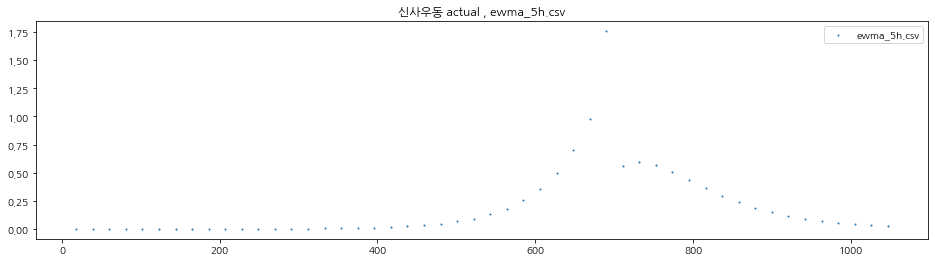

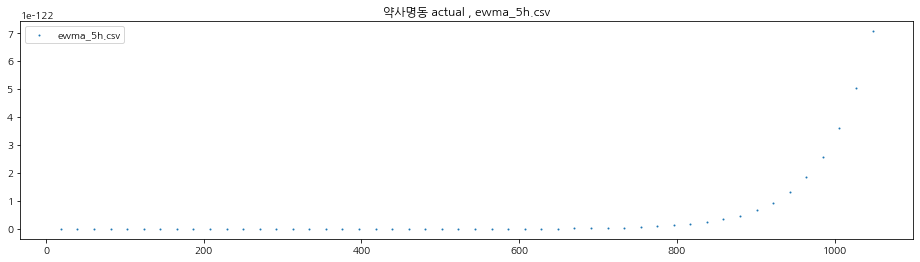

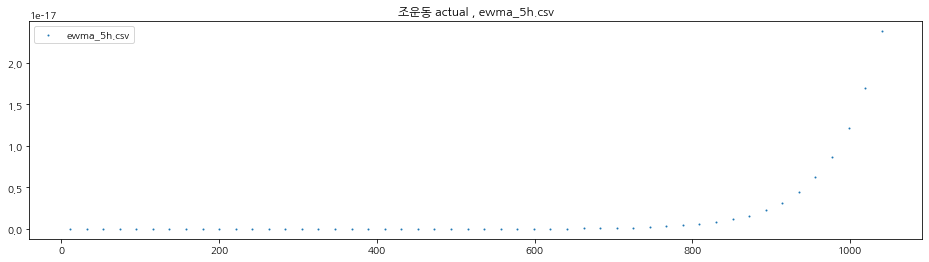

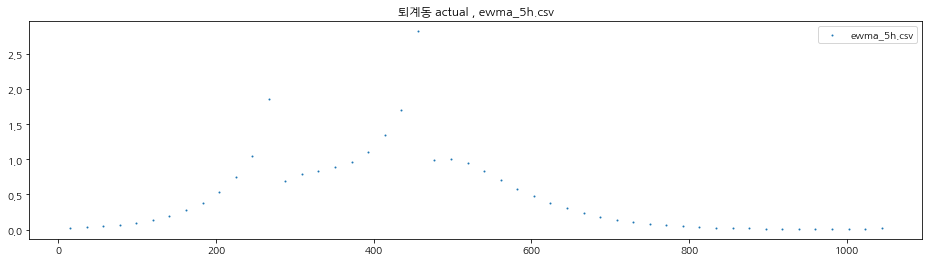

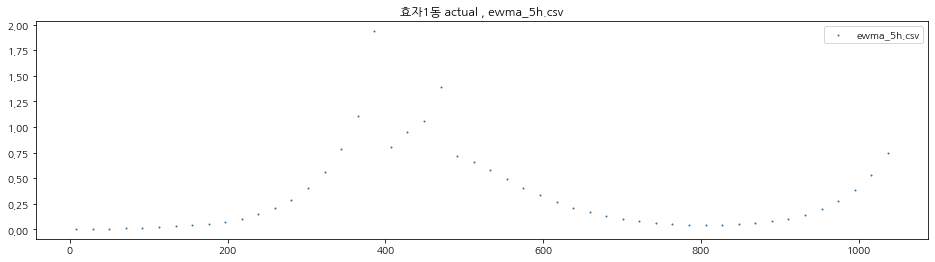

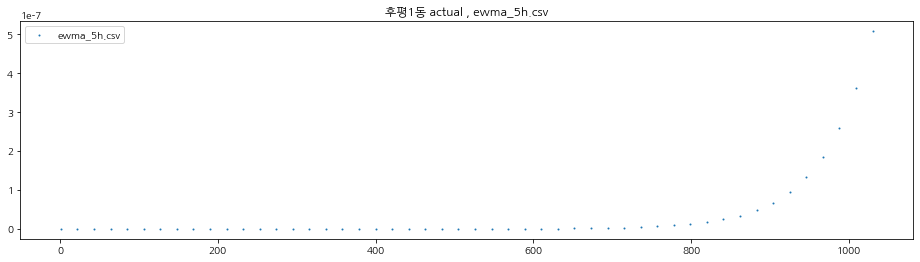

In [15]:
dong_actual('ewma_5h.csv')